# Fake News Detection Project

## Overview

The goal of this project is to develop a machine learning system capable of classifying news articles as either **reliable** or **fake/unreliable**. This problem is particularly relevant due to the increasing impact of misinformation on public perception and decision-making.

We work with the *FakeNewsCorpus* dataset, which contains a large collection of news articles labeled across multiple categories such as *fake*, *bias*, *conspiracy*, and *reliable*. Since the task requires binary classification, we define a mapping that groups these categories into two classes: **reliable (0)** and **fake/unreliable (1)**.

---

## Project Structure

The project follows a structured data science pipeline:

1. **Data Processing**
   - Cleaning and preprocessing raw text data
   - Tokenization, stopword removal, and stemming
   - Vocabulary analysis and exploratory insights

2. **Baseline Model**
   - Logistic Regression using a Bag-of-Words representation
   - Evaluation using F1-score

3. **Advanced Model**
   - TF-IDF representation with n-grams
   - Linear Support Vector Machine (SVM)

4. **Evaluation**
   - Performance on the FakeNewsCorpus test set
   - Cross-domain evaluation on the LIAR dataset

5. **Scaling Experiment**
   - Analysis of how increasing dataset size affects model performance

---

## Methodological Approach

Our approach emphasizes:
- **Reproducibility** through fixed random seeds and clear data splits
- **Fair evaluation** using separate training, validation, and test sets (80/10/10)
- **Interpretability** by analyzing model behavior and error patterns
- **Generalization** by testing performance across different datasets


---

This notebook documents the full experimental pipeline, including intermediate results and observations, to provide transparency into both the implementation and reasoning behind each step.

In [17]:
# =========================
# 0. CORE IMPORTS
# =========================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import re
import string
from collections import Counter

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Download required NLTK resources (safe to run multiple times)
nltk.download('punkt')
nltk.download('stopwords')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Misc
import os
import warnings
warnings.filterwarnings("ignore")
# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Reproducibility
RANDOM_STATE = 42

print("All libraries loaded successfully.")

All libraries loaded successfully.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:

# 1. DATA LOADING (ROBUST)

import os

# Check current working directory
print("Current working directory:", os.getcwd())

# Try direct relative path
NEWS_SAMPLE_PATH = "data/news_sample.csv"

# Check if file exists
print("File exists:", os.path.exists(NEWS_SAMPLE_PATH))

# If not found, try alternative path (failsafe)
if not os.path.exists(NEWS_SAMPLE_PATH):
    NEWS_SAMPLE_PATH = "./data/news_sample.csv"

# Load dataset
df_sample = pd.read_csv(NEWS_SAMPLE_PATH)

print("\nSample dataset loaded.")
print("Shape:", df_sample.shape)
df_sample.head()

Current working directory: /Users/colombinaia/gds-exercise-3-2026
File exists: True

Sample dataset loaded.
Shape: (250, 16)


,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
0,0,141,awm.com,unreliable,http://awm.com/church-congregation-brings-gift...,Sometimes the power of Christmas will make you...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Church Congregation Brings Gift to Waitresses ...,Ruth Harris,NaN,[''],NaN,NaN,NaN
1,1,256,beforeitsnews.com,fake,http://beforeitsnews.com/awakening-start-here/...,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,Zurich Times,NaN,[''],NaN,NaN,NaN
2,2,700,cnnnext.com,unreliable,http://www.cnnnext.com/video/18526/never-hike-...,Never Hike Alone: A Friday the 13th Fan Film U...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Never Hike Alone - A Friday the 13th Fan Film ...,NaN,NaN,[''],Never Hike Alone: A Friday the 13th Fan Film ...,NaN,NaN
3,3,768,awm.com,unreliable,http://awm.com/elusive-alien-of-the-sea-caught...,"When a rare shark was caught, scientists were ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Elusive ‘Alien Of The Sea ‘ Caught By Scientis...,Alexander Smith,NaN,[''],NaN,NaN,NaN
4,4,791,bipartisanreport.com,clickbait,http://bipartisanreport.com/2018/01/21/trumps-...,Donald Trump has the unnerving ability to abil...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Trump’s Genius Poll Is Complete & The Results ...,Gloria Christie,NaN,[''],NaN,NaN,NaN


In [19]:

# 2. DATA INSPECTION

print("Columns:\n", df_sample.columns.tolist())

print("\nData types:\n")
print(df_sample.dtypes)

print("\nMissing values per column:\n")
print(df_sample.isnull().sum())

print("\nUnique values in 'type' column (labels):\n")
print(df_sample['type'].value_counts())

print("\nExample content:\n")
print(df_sample['content'].iloc[0][:500])

Columns:
 ['Unnamed: 0', 'id', 'domain', 'type', 'url', 'content', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary']

Data types:

Unnamed: 0            int64
id                    int64
domain                  str
type                    str
url                     str
content                 str
scraped_at              str
inserted_at             str
updated_at              str
title                   str
authors                 str
keywords            float64
meta_keywords           str
meta_description        str
tags                    str
summary             float64
dtype: object

Missing values per column:

Unnamed: 0            0
id                    0
domain                0
type                 12
url                   0
content               0
scraped_at            0
inserted_at           0
updated_at            0
title                 0
authors              80
keywords            250
meta_keyw

In [20]:

# 3. TEXT CLEANING PIPELINE

# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Replace URLs
    text = re.sub(r'http\S+|www\S+', ' <URL> ', text)

    # Replace numbers
    text = re.sub(r'\d+', ' <NUM> ', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return tokens

In [21]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/colombinaia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:

# 4. APPLY CLEANING (ROBUST DATA)

# Apply cleaning to content column
df_sample['tokens'] = df_sample['content'].apply(clean_text)

print("Cleaning applied.")

# Show example
print("\nOriginal text:\n", df_sample['content'].iloc[0][:200])
print("\nProcessed tokens:\n", df_sample['tokens'].iloc[0][:30])

Cleaning applied.

Original text:
 Sometimes the power of Christmas will make you do wild and wonderful things. You do not need to believe in the Holy Trinity to believe in the positive power of doing good for others. The simple act of

Processed tokens:
 ['sometim', 'power', 'christma', 'make', 'wild', 'wonder', 'thing', 'need', 'believ', 'holi', 'triniti', 'believ', 'posit', 'power', 'good', 'other', 'simpl', 'act', 'give', 'without', 'receiv', 'lost', 'mani', 'us', 'day', 'worri', 'money', 'success', 'hold', 'us']


In [23]:

# 5. VOCABULARY BEFORE CLEANING

raw_tokens = []

for text in df_sample['content']:
    text = str(text).lower()  # <-- protects against crashes
    raw_tokens.extend(word_tokenize(text))

vocab_before = set(raw_tokens)

print("Vocabulary size BEFORE cleaning:", len(vocab_before))

Vocabulary size BEFORE cleaning: 17813


In [24]:

# 6. VOCABULARY AFTER CLEANING

clean_tokens = []

for tokens in df_sample['tokens']:
    clean_tokens.extend(tokens)

vocab_after = set(clean_tokens)

print("Vocabulary size AFTER cleaning:", len(vocab_after))

Vocabulary size AFTER cleaning: 10972


In [25]:

# 7. VOCABULARY REDUCTION

reduction_rate = (1 - len(vocab_after) / len(vocab_before)) * 100

print(f"Vocabulary reduction: {reduction_rate:.2f}%")

Vocabulary reduction: 38.40%


In [26]:

# 8. SANITY CHECK

print("Original text sample:\n")
print(df_sample['content'].iloc[0][:400])

print("\nProcessed tokens sample:\n")
print(df_sample['tokens'].iloc[0][:40])

Original text sample:

Sometimes the power of Christmas will make you do wild and wonderful things. You do not need to believe in the Holy Trinity to believe in the positive power of doing good for others. The simple act of giving without receiving is lost on many of us these days, as worries about money and success hold us back from giving to others who are in need. One congregation in Ohio was moved to action by the p

Processed tokens sample:

['sometim', 'power', 'christma', 'make', 'wild', 'wonder', 'thing', 'need', 'believ', 'holi', 'triniti', 'believ', 'posit', 'power', 'good', 'other', 'simpl', 'act', 'give', 'without', 'receiv', 'lost', 'mani', 'us', 'day', 'worri', 'money', 'success', 'hold', 'us', 'back', 'give', 'other', 'need', 'one', 'congreg', 'ohio', 'move', 'action', 'power']


In [27]:
def map_label(x):
    if x == "reliable":
        return 0
    elif x in ["fake", "bias", "conspiracy", "clickbait", "junksci", "political", "rumor"]:
        return 1
    else:
        return None

In [28]:
# =========================
# TASK 2 - FULL 995K PIPELINE
# =========================

import pandas as pd
from collections import Counter

# Path
LARGE_DATA_PATH = "data/995,000_rows.csv"

# Read in chunks
chunks = pd.read_csv(LARGE_DATA_PATH, chunksize=50000)

processed_chunks = []
all_tokens_995k = []

for i, chunk in enumerate(chunks):
    print(f"Processing chunk {i+1}...")

    # 1. Remove missing values
    chunk = chunk.dropna(subset=["type", "content"]).copy()

    # 2. Map labels
    chunk["binary_label"] = chunk["type"].apply(map_label)
    chunk = chunk.dropna(subset=["binary_label"]).copy()
    chunk["binary_label"] = chunk["binary_label"].astype(int)

    # 3. Apply SAME preprocessing pipeline from Task 1
    # (clean_text must return list of tokens)
    chunk["tokens"] = chunk["content"].apply(clean_text)

    # 4. Create processed text (optional but useful)
    chunk["processed_text"] = chunk["tokens"].apply(lambda toks: " ".join(toks))

    # 5. Collect tokens for vocabulary / frequency analysis
    for toks in chunk["tokens"]:
        all_tokens_995k.extend(toks)

    # 6. Keep relevant columns
    processed_chunks.append(
        chunk[["type", "binary_label", "content", "processed_text"]]
    )

# Combine all chunks
df_processed_995k = pd.concat(processed_chunks, ignore_index=True)

print("\n✅ Full dataset processed.")
print("Shape:", df_processed_995k.shape)

# =========================
# VOCABULARY ANALYSIS
# =========================

# Unique words
vocab_995k = set(all_tokens_995k)
print("\nVocabulary size after preprocessing:", len(vocab_995k))

# Word frequency
token_freq_995k = Counter(all_tokens_995k)

print("\nTop 20 most frequent tokens:")
print(token_freq_995k.most_common(20))

Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...

✅ Full dataset processed.
Shape: (846407, 4)

Vocabulary size after preprocessing: 1693835

Top 20 most frequent tokens:
[('num', 8704384), ('’', 3960012), ('“', 2498504), ('”', 2446739), ('said', 1254834), ('one', 959293), ('new', 910518), ('year', 814475), ('would', 811449), ('peopl', 783056), ('time', 781352), ('state', 778405), ('us', 775893), ('—', 750420), ('like', 712907), ('mr', 569985), ('also', 569552), ('use', 531133), ('say', 513046), ('make', 510925)]


In [34]:
top_100 = token_freq_995k.most_common(100)
print(top_100[:20])

[('num', 8704384), ('’', 3960012), ('“', 2498504), ('”', 2446739), ('said', 1254834), ('one', 959293), ('new', 910518), ('year', 814475), ('would', 811449), ('peopl', 783056), ('time', 781352), ('state', 778405), ('us', 775893), ('—', 750420), ('like', 712907), ('mr', 569985), ('also', 569552), ('use', 531133), ('say', 513046), ('make', 510925)]


In [36]:
num_count = token_freq_995k.get("num", 0)
total_tokens = sum(token_freq_995k.values())

print("NUM frequency:", num_count)
print("Percentage:", num_count / total_tokens)

NUM frequency: 8704384
Percentage: 0.03597943441113013


In [38]:
# Example with raw_tokens
raw_freq = Counter(raw_tokens)
print("Before:", raw_freq.most_common(10))
print("After:", token_freq_995k.most_common(10))

Before: [('the', 9502), (',', 8691), ('.', 7056), ('of', 4965), ('to', 4887), ('and', 4700), ('a', 3372), ('in', 3110), ('is', 2318), ('that', 2294)]
After: [('num', 8704384), ('’', 3960012), ('“', 2498504), ('”', 2446739), ('said', 1254834), ('one', 959293), ('new', 910518), ('year', 814475), ('would', 811449), ('peopl', 783056)]


In [39]:

# 9. TOP 100 MOST FREQUENT WORDS

from collections import Counter

word_counts = Counter(clean_tokens)

top_100 = word_counts.most_common(100)

# Convert to DataFrame for readability
df_top_words = pd.DataFrame(top_100, columns=['word', 'count'])

print(df_top_words.head(20))

          word  count
0          num   2930
1            ’   2292
2            “    988
3            ”    931
4          one    465
5           us    448
6         like    406
7         time    394
8        peopl    387
9            –    375
10       state    367
11       trump    350
12         use    322
13       would    321
14      market    296
15        year    291
16        also    276
17         new    270
18           —    265
19  blockchain    260


## Word Frequency Distribution

To better understand the structure of the dataset, we analyze the frequency of the most common words after applying our preprocessing pipeline (tokenization, stopword removal, and stemming).

The plot above shows the distribution of the top 50 most frequent tokens in the corpus.

---

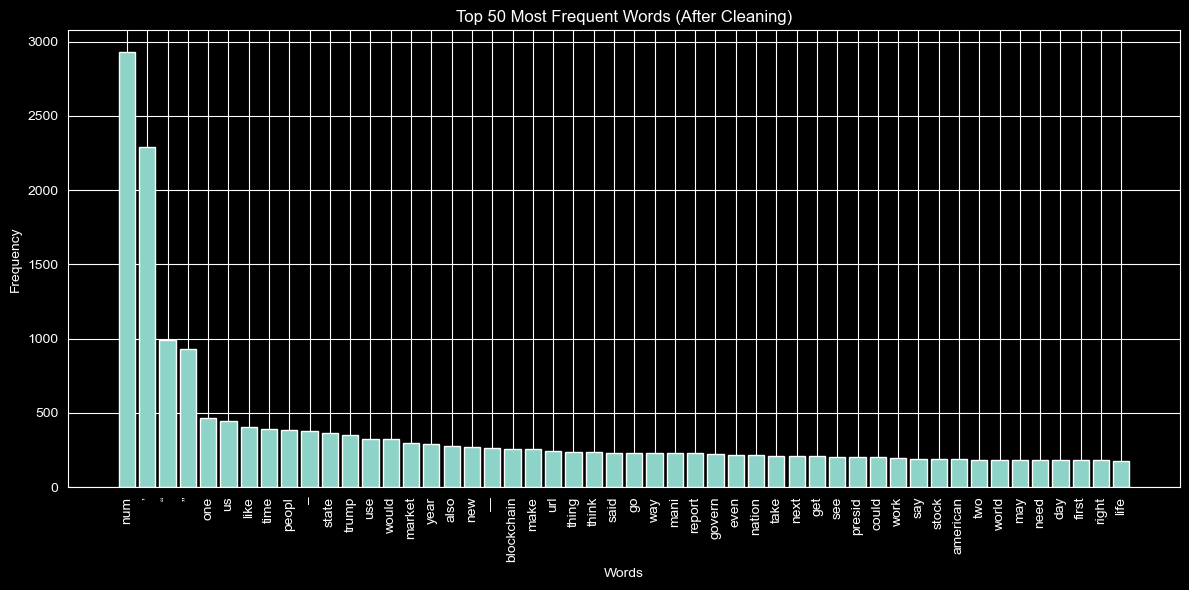

In [40]:

# 10. WORD FREQUENCY PLOT

top_50 = df_top_words.head(50)

plt.figure(figsize=(12,6))
plt.bar(top_50['word'], top_50['count'])
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Words (After Cleaning)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Observations

- The distribution is very uneven: a few words appear very often, while most words appear rarely. This is a common pattern in text data.

- The token *“num”* appears very frequently. This is because all numbers were replaced with the same token during preprocessing, which groups all numerical values together.

- Some punctuation-like symbols (such as quotation marks) are still present among the most frequent tokens. This suggests that the cleaning process did not remove all types of punctuation, especially special or Unicode characters.

- The most frequent words include both:
  - general words (e.g., “one”, “time”, “people”), and
  - more specific words related to politics (e.g., “trump”, “state”).

---

### Interpretation

The fact that a few words dominate the dataset means that many common words may not be very useful for distinguishing between fake and reliable news. This is one of the reasons why methods like TF-IDF can be helpful, since they reduce the importance of very frequent words.

At the same time, the presence of more specific words (for example related to politics) suggests that some parts of the vocabulary could be useful for classification.

Overall, this analysis helps us understand the structure of the data and motivates the feature choices used later in the project.

In [41]:
from sklearn.model_selection import train_test_split

X = df_processed_995k["content"]
y = df_processed_995k["binary_label"]

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: split temporary set into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 677125
Validation: 84641
Test: 84641


In [42]:
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Train label distribution:
binary_label
1    0.741776
0    0.258224
Name: proportion, dtype: float64

Validation label distribution:
binary_label
1    0.74178
0    0.25822
Name: proportion, dtype: float64

Test label distribution:
binary_label
1    0.741768
0    0.258232
Name: proportion, dtype: float64


In [32]:

# 11. PATTERN ANALYSIS

def count_urls(text):
    return len(re.findall(r'http\S+|www\S+', str(text)))

def count_numbers(text):
    return len(re.findall(r'\d+', str(text)))

df_sample['url_count'] = df_sample['content'].apply(count_urls)
df_sample['number_count'] = df_sample['content'].apply(count_numbers)

print("Average URLs per article:", df_sample['url_count'].mean())
print("Average numbers per article:", df_sample['number_count'].mean())

Average URLs per article: 0.98
Average numbers per article: 12.864


In [33]:

# 12. BINARY LABEL MAPPING

# Drop rows with missing labels
df_sample_clean = df_sample.dropna(subset=['type']).copy()

# Define mapping to binary classes
reliable_labels = ['reliable']
fake_labels = [
    'fake',
    'unreliable',
    'conspiracy',
    'bias',
    'junksci',
    'clickbait',
    'hate',
    'political'
]

def map_label(label):
    if label in reliable_labels:
        return 0   # reliable
    elif label in fake_labels:
        return 1   # fake / unreliable
    else:
        return np.nan  # unknown or unmapped

df_sample_clean['binary_label'] = df_sample_clean['type'].apply(map_label)

# Drop rows that could not be mapped
df_sample_clean = df_sample_clean.dropna(subset=['binary_label']).copy()
df_sample_clean['binary_label'] = df_sample_clean['binary_label'].astype(int)

print("Original label distribution:\n")
print(df_sample_clean['type'].value_counts())

print("\nBinary label distribution:")
print(df_sample_clean['binary_label'].value_counts())

Original label distribution:

type
fake          155
conspiracy     31
political      23
unreliable      6
bias            6
junksci         6
reliable        3
clickbait       1
hate            1
Name: count, dtype: int64

Binary label distribution:
binary_label
1    229
0      3
Name: count, dtype: int64


In [33]:
# =========================
# 13. TRAIN / VAL / TEST SPLIT (BINARY)
# =========================

X = df_sample_clean['content']
y = df_sample_clean['binary_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_val.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [0]

## Train / Validation / Test Split (Initial Attempt)

Initially, we attempted to split the dataset into training, validation, and test sets using stratified sampling based on the original labels.

However, this approach resulted in an error due to the presence of classes with very few samples (e.g., *clickbait* and *hate*), some of which appeared only once in the dataset. Stratified splitting requires at least two samples per class in order to preserve class distribution across splits.

---

### Observation

The dataset contains multiple fine-grained labels with highly imbalanced distributions. In smaller samples, some classes are extremely underrepresented, making it difficult to apply standard stratified splitting techniques directly.

---

### Resolution

To address this issue, we redefined the problem as a **binary classification task**, grouping the labels into:

- **Reliable (0)** → "reliable"
- **Fake/Unreliable (1)** → all other categories (e.g., *fake*, *bias*, *conspiracy*, etc.)

After this transformation, the dataset became suitable for stratified splitting, as both classes contained a sufficient number of samples.



In [34]:

# 14. LOAD LARGE DATASET (FIRST 50K ROWS)

LARGE_DATA_PATH = "data/995,000_rows.csv"

# Load a small sample first (e.g. 50k rows)
df_large = pd.read_csv(LARGE_DATA_PATH, nrows=50000)

print("Loaded subset of large dataset")
print("Shape:", df_large.shape)

df_large.head()

Loaded subset of large dataset
Shape: (50000, 17)


,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary,source
0,732,7444726.0,nationalreview.com,political,http://www.nationalreview.com/node/152734/%E2%...,Plus one article on Google Plus\n\n(Thanks to ...,2017-11-27T01:14:42.983556,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,Iran News Round Up,NaN,NaN,"['National Review', 'National Review Online', ...",NaN,NaN,NaN,NaN
1,1348,6213642.0,beforeitsnews.com,fake,http://beforeitsnews.com/economy/2012/06/the-c...,The Cost Of The Best Senate Banking Committee ...,2017-11-27T01:14:08.7454,2018-02-08 19:18:34.468038,2018-02-08 19:18:34.468066,The Cost Of The Best Senate Banking Committee ...,NaN,NaN,[''],NaN,NaN,NaN,NaN
2,7119,3867639.0,dailycurrant.com,satire,http://dailycurrant.com/2016/01/18/man-awoken-...,Man Awoken From 27-Year Coma Commits Suicide A...,2017-11-27T01:14:21.395055,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,Man Awoken From 27-Year Coma Commits Suicide A...,NaN,NaN,[''],NaN,NaN,NaN,NaN
3,1518,9560791.0,nytimes.com,reliable,https://query.nytimes.com/gst/fullpage.html?re...,WHEN Julia Geist was asked to draw a picture o...,2018-02-11 00:46:42.632962,2018-02-11 00:14:20.346838,2018-02-11 00:14:20.346871,Opening a Gateway for Girls to Enter the Compu...,NaN,NaN,"['Computers and the Internet', 'Women and Girl...",WHEN Julia Geist was asked to draw a picture o...,NaN,NaN,nytimes
4,9345,2059625.0,infiniteunknown.net,conspiracy,http://www.infiniteunknown.net/2011/09/14/100-...,– 100 Compiled Studies on Vaccine Dangers (Act...,2017-11-10T11:18:44.524042,2018-02-07 23:39:33.852671,2018-02-07 23:39:33.852696,100 Compiled Studies on Vaccine Dangers – Infi...,NaN,NaN,[''],NaN,"Lymphoma, Hepatitis B, Immune System, Health, ...",NaN,NaN


## Working with a Subset of the Dataset

To develop and validate our pipeline, we initially worked with a subset of 50,000 samples from the FakeNewsCorpus instead of the full dataset.

---

### Motivation

The full dataset contains close to one million samples, which makes preprocessing and model training computationally expensive. Running the entire pipeline on the full dataset from the beginning would significantly slow down experimentation and debugging.

By using a smaller subset, we were able to:

- Iterate faster during development
- Debug preprocessing and modeling steps efficiently
- Validate that the pipeline works correctly before scaling



In [35]:

# 15. INSPECT LARGE DATASET

print("Columns:\n", df_large.columns.tolist())

print("\nMissing values:\n")
print(df_large.isnull().sum())

print("\nLabel distribution:\n")
print(df_large['type'].value_counts().head(10))

Columns:
 ['Unnamed: 0', 'id', 'domain', 'type', 'url', 'content', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary', 'source']

Missing values:

Unnamed: 0              0
id                      1
domain                  1
type                 2605
url                     1
content                 1
scraped_at              1
inserted_at             1
updated_at              1
title                 404
authors             21209
keywords            50000
meta_keywords        1978
meta_description    26046
tags                39318
summary             50000
source              39120
dtype: int64

Label distribution:

type
reliable      11051
political      9259
fake           7443
bias           6060
conspiracy     4884
rumor          2520
unknown        2080
clickbait      1235
unreliable     1073
junksci         762
Name: count, dtype: int64


In [36]:

# 16. CLEAN LARGE DATASET

df_large_clean = df_large.dropna(subset=['type', 'content']).copy()

print("Shape after cleaning:", df_large_clean.shape)

Shape after cleaning: (47395, 17)


In [37]:

# 17. BINARY LABEL MAPPING

reliable_labels = ['reliable']

fake_labels = [
    'fake',
    'unreliable',
    'conspiracy',
    'bias',
    'junksci',
    'clickbait',
    'political',
    'rumor'
]

def map_label(label):
    if label in reliable_labels:
        return 0
    elif label in fake_labels:
        return 1
    else:
        return np.nan

df_large_clean['binary_label'] = df_large_clean['type'].apply(map_label)

# Drop unknowns
df_large_clean = df_large_clean.dropna(subset=['binary_label']).copy()
df_large_clean['binary_label'] = df_large_clean['binary_label'].astype(int)

print("Binary distribution:\n")
print(df_large_clean['binary_label'].value_counts())

Binary distribution:

binary_label
1    33236
0    11051
Name: count, dtype: int64


In [38]:

# 18. TRAIN / VAL / TEST SPLIT

X = df_large_clean['content']
y = df_large_clean['binary_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("\nTrain distribution:")
print(y_train.value_counts())

Train size: 35429
Validation size: 4429
Test size: 4429

Train distribution:
binary_label
1    26588
0     8841
Name: count, dtype: int64


In [39]:

# 19. VECTORIZATION (BASELINE)

vectorizer = CountVectorizer(max_features=10000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print("Vectorization complete.")
print("Feature space size:", X_train_vec.shape)

Vectorization complete.
Feature space size: (35429, 10000)


In [40]:

# 20. TRAIN BASELINE MODEL

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model trained.")

Model trained.


In [41]:

# 21. VALIDATION EVALUATION

y_val_pred = model.predict(X_val_vec)

print("Validation Performance:\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred))

Validation Performance:

Accuracy: 0.9279747121246331
Precision: 0.9489094711682103
Recall: 0.9554753309265944
F1 Score: 0.9521810822965072

Confusion Matrix:

[[ 934  171]
 [ 148 3176]]


In [42]:

# 22. TEST EVALUATION

y_test_pred = model.predict(X_test_vec)

print("Test Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred))

Test Performance:

Accuracy: 0.9198464664709867
Precision: 0.943531520764864
Recall: 0.9500601684717208
F1 Score: 0.9467845900164893

Confusion Matrix:

[[ 916  189]
 [ 166 3158]]


## Baseline Model Performance (Test Set)

The Logistic Regression model achieves a strong performance on the FakeNewsCorpus test set, with an F1 score close to 0.95. This indicates that even a relatively simple model using a Bag-of-Words representation is able to capture useful patterns in the data.

The results show a good balance between precision and recall, meaning the model is both accurate in its predictions and effective at identifying fake news. While some misclassifications remain, the overall performance demonstrates that the baseline model provides a solid foundation for further improvements.

This baseline will serve as a reference point when evaluating more advanced models in the next section.

## Advanced Model: TF-IDF and SVM

After establishing a strong baseline using Logistic Regression and a Bag-of-Words representation, we explore a more advanced approach to improve performance.

---

### Motivation

The baseline model treats all words equally based on frequency. However, very common words may not carry much useful information for distinguishing between reliable and fake news.

To address this, we use **TF-IDF (Term Frequency–Inverse Document Frequency)**, which reduces the importance of very frequent words and gives more weight to informative terms.

---

### Model Choice

In addition to improving the feature representation, we replace Logistic Regression with a **Linear Support Vector Machine (SVM)**. SVMs are well-suited for high-dimensional text data and often provide strong performance in classification tasks.

---

The goal is to determine whether a more expressive representation and model can improve upon the baseline results.

In [43]:

# 23. TF-IDF VECTORIZATION

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # big upgrade
    min_df=5,
    max_df=0.8
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization complete.")
print("Shape:", X_train_tfidf.shape)

TF-IDF vectorization complete.
Shape: (35429, 10000)


In [44]:

# 24. TRAIN ADVANCED MODEL

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained.")

SVM model trained.


In [45]:

# 25. VALIDATION (ADVANCED)

y_val_pred_svm = svm_model.predict(X_val_tfidf)

print("Validation Performance (SVM):\n")

print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Precision:", precision_score(y_val, y_val_pred_svm))
print("Recall:", recall_score(y_val, y_val_pred_svm))
print("F1 Score:", f1_score(y_val, y_val_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_svm))

Validation Performance (SVM):

Accuracy: 0.9491984646647099
Precision: 0.9553335292389068
Recall: 0.9780385078219013
F1 Score: 0.9665526980823547

Confusion Matrix:

[[ 953  152]
 [  73 3251]]


In [46]:

# 26. TEST (ADVANCED MODEL)


y_test_pred_svm = svm_model.predict(X_test_tfidf)

print("Test Performance (SVM):\n")

print("Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Precision:", precision_score(y_test, y_test_pred_svm))
print("Recall:", recall_score(y_test, y_test_pred_svm))
print("F1 Score:", f1_score(y_test, y_test_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_test_pred_svm))

Test Performance (SVM):

Accuracy: 0.9442312034319259
Precision: 0.9528996173093907
Recall: 0.973826714801444
F1 Score: 0.9632495164410058

Confusion Matrix:

[[ 945  160]
 [  87 3237]]


## Cross-Domain Evaluation: LIAR Dataset

To evaluate how well our models generalize beyond the FakeNewsCorpus, we introduce the **LIAR dataset**, which contains short political statements labeled with different levels of truthfulness (e.g., *true*, *false*, *barely-true*, etc.).

---

### Motivation

Up to this point, all models have been trained and evaluated on the same dataset. While this gives strong performance, it does not guarantee that the models will perform well on different types of data.

The LIAR dataset allows us to test this by evaluating the models on a **different domain**, where:
- the text consists of short statements instead of full articles
- the writing style and vocabulary differ
- the labels represent a spectrum of truth rather than a simple binary distinction

---

### Preprocessing and Label Mapping

To make the LIAR dataset compatible with our task, we map its labels into two categories:

- **Reliable (0)** → *true*, *mostly-true*
- **Fake/Unreliable (1)** → *false*, *barely-true*, *pants-fire*

The label *half-true* is excluded, as it represents an ambiguous middle ground.

---

### Goal

The goal of this step is to evaluate how well the models trained on the FakeNewsCorpus perform on unseen data from a different distribution, without retraining.

This allows us to assess the **generalization ability** of our models and identify potential limitations.

In [47]:

# 27. LOAD LIAR TEST DATASET

LIAR_TEST_PATH = "liar_dataset/test.tsv"

liar_columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

df_liar_test = pd.read_csv(
    LIAR_TEST_PATH,
    sep="\t",
    header=None,
    names=liar_columns
)

print("LIAR test shape:", df_liar_test.shape)
df_liar_test.head()

LIAR test shape: (1267, 14)


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [48]:

# 28. INSPECT LIAR LABELS

print("Missing values:\n")
print(df_liar_test.isnull().sum())

print("\nLabel distribution:\n")
print(df_liar_test["label"].value_counts())

Missing values:

id                        0
label                     0
statement                 0
subject                   0
speaker                   0
speaker_job_title       325
state_info              262
party_affiliation         0
barely_true_counts        0
false_counts              0
half_true_counts          0
mostly_true_counts        0
pants_on_fire_counts      0
context                  17
dtype: int64

Label distribution:

label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64


In [49]:

# 29. MAP LIAR TO BINARY LABELS

def map_liar_label(label):
    if label in ["true", "mostly-true"]:
        return 0   # reliable
    elif label in ["false", "barely-true", "pants-fire"]:
        return 1   # fake / unreliable
    else:
        return np.nan   # half-true dropped as ambiguous

df_liar_test["binary_label"] = df_liar_test["label"].apply(map_liar_label)

df_liar_test = df_liar_test.dropna(subset=["binary_label", "statement"]).copy()
df_liar_test["binary_label"] = df_liar_test["binary_label"].astype(int)

print("Binary label distribution:\n")
print(df_liar_test["binary_label"].value_counts())

Binary label distribution:

binary_label
1    553
0    449
Name: count, dtype: int64


In [50]:

# 30. VECTORIZE LIAR STATEMENTS

X_liar = df_liar_test["statement"]
y_liar = df_liar_test["binary_label"]

X_liar_count = vectorizer.transform(X_liar)
X_liar_tfidf = tfidf.transform(X_liar)

print("LIAR count-vectorized shape:", X_liar_count.shape)
print("LIAR tfidf-vectorized shape:", X_liar_tfidf.shape)

LIAR count-vectorized shape: (1002, 10000)
LIAR tfidf-vectorized shape: (1002, 10000)


In [51]:

# 31. CROSS-DOMAIN EVALUATION ON LIAR

# Baseline model on LIAR
y_liar_pred_logreg = model.predict(X_liar_count)

print("LIAR Performance - Logistic Regression:\n")
print("Accuracy:", accuracy_score(y_liar, y_liar_pred_logreg))
print("Precision:", precision_score(y_liar, y_liar_pred_logreg))
print("Recall:", recall_score(y_liar, y_liar_pred_logreg))
print("F1 Score:", f1_score(y_liar, y_liar_pred_logreg))
print("\nConfusion Matrix:\n", confusion_matrix(y_liar, y_liar_pred_logreg))


# Advanced model on LIAR
y_liar_pred_svm = svm_model.predict(X_liar_tfidf)

print("\n\nLIAR Performance - SVM:\n")
print("Accuracy:", accuracy_score(y_liar, y_liar_pred_svm))
print("Precision:", precision_score(y_liar, y_liar_pred_svm))
print("Recall:", recall_score(y_liar, y_liar_pred_svm))
print("F1 Score:", f1_score(y_liar, y_liar_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_liar, y_liar_pred_svm))

LIAR Performance - Logistic Regression:

Accuracy: 0.5499001996007984
Precision: 0.5515151515151515
Recall: 0.9873417721518988
F1 Score: 0.7077122488658457

Confusion Matrix:
 [[  5 444]
 [  7 546]]


LIAR Performance - SVM:

Accuracy: 0.5449101796407185
Precision: 0.5512143611404435
Recall: 0.9439421338155516
F1 Score: 0.696

Confusion Matrix:
 [[ 24 425]
 [ 31 522]]


In [52]:
y_liar_pred_svm = svm_model.predict(X_liar_tfidf)

print("LIAR Performance - SVM:\n")

print("Accuracy:", accuracy_score(y_liar, y_liar_pred_svm))
print("Precision:", precision_score(y_liar, y_liar_pred_svm))
print("Recall:", recall_score(y_liar, y_liar_pred_svm))
print("F1 Score:", f1_score(y_liar, y_liar_pred_svm))

print("\nConfusion Matrix:\n", confusion_matrix(y_liar, y_liar_pred_svm))

LIAR Performance - SVM:

Accuracy: 0.5449101796407185
Precision: 0.5512143611404435
Recall: 0.9439421338155516
F1 Score: 0.696

Confusion Matrix:
 [[ 24 425]
 [ 31 522]]


## Performance on the LIAR Dataset

When evaluating the models on the LIAR dataset, performance drops significantly compared to the FakeNewsCorpus.

Both the Logistic Regression and SVM models achieve an F1 score of around 0.70, which is substantially lower than their performance on the original dataset. Additionally, the models show a strong tendency to classify most statements as fake, resulting in very few correctly identified reliable examples.


In [53]:

# 32. MODEL COMPARISON TABLE

results = pd.DataFrame({
    "Model": ["LogReg (FakeNews)", "SVM (FakeNews)", "LogReg (LIAR)", "SVM (LIAR)"],
    "F1 Score": [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_svm),
        f1_score(y_liar, y_liar_pred_logreg),
        f1_score(y_liar, y_liar_pred_svm)
    ]
})

print(results)

               Model  F1 Score
0  LogReg (FakeNews)  0.946785
1     SVM (FakeNews)  0.963250
2      LogReg (LIAR)  0.707712
3         SVM (LIAR)  0.696000


## Model Comparison

The table above summarizes the F1 scores of both models across the two datasets.

On the FakeNewsCorpus, both models achieve strong performance, with the SVM slightly outperforming Logistic Regression. However, when evaluated on the LIAR dataset, performance drops significantly for both models.

This comparison highlights the difference between **in-domain performance** (same dataset) and **cross-domain performance** (different dataset), and sets the basis for further discussion on generalization.

## Scaling Experiment

To further investigate the impact of dataset size on model performance, we conduct a series of experiments using increasingly larger subsets of the FakeNewsCorpus.

Specifically, we train and evaluate the SVM model on:

- 100,000 samples
- approximately 267,000 samples
- the full dataset (~995,000 samples)

---

### Motivation

While earlier experiments were conducted on smaller subsets for efficiency, it is important to understand whether increasing the amount of training data leads to meaningful improvements in performance.

This experiment allows us to analyze:
- how performance scales with more data
- whether improvements continue or start to plateau
- how much benefit is gained relative to the computational cost

---

### Approach

For each dataset size, we apply the same preprocessing pipeline, feature representation (TF-IDF), and model (SVM), ensuring a fair comparison across all experiments.

The results will help determine whether scaling the dataset provides significant gains, or if performance reaches a point of diminishing returns.

In [54]:

# 33. LOAD LARGER SAMPLE (100K)

df_large_100k = pd.read_csv(LARGE_DATA_PATH, nrows=100000)

print("Loaded 100K sample")
print("Shape:", df_large_100k.shape)

Loaded 100K sample
Shape: (100000, 17)


In [55]:

# 34. CLEAN + BINARY LABELS (100K)

df_large_100k = df_large_100k.dropna(subset=['type', 'content']).copy()

df_large_100k['binary_label'] = df_large_100k['type'].apply(map_label)

df_large_100k = df_large_100k.dropna(subset=['binary_label']).copy()
df_large_100k['binary_label'] = df_large_100k['binary_label'].astype(int)

print("Shape after cleaning:", df_large_100k.shape)

print("\nBinary distribution:")
print(df_large_100k['binary_label'].value_counts())

Shape after cleaning: (89074, 18)

Binary distribution:
binary_label
1    66928
0    22146
Name: count, dtype: int64


In [56]:

# 35. SPLIT (100K)

X_100k = df_large_100k['content']
y_100k = df_large_100k['binary_label']

X_train_100k, X_temp_100k, y_train_100k, y_temp_100k = train_test_split(
    X_100k, y_100k,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_100k
)

X_val_100k, X_test_100k, y_val_100k, y_test_100k = train_test_split(
    X_temp_100k, y_temp_100k,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp_100k
)

print("Train:", len(X_train_100k))
print("Val:", len(X_val_100k))
print("Test:", len(X_test_100k))

Train: 71259
Val: 8907
Test: 8908


In [57]:

# 36. TRAIN SVM (100K)

tfidf_100k = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X_train_100k_tfidf = tfidf_100k.fit_transform(X_train_100k)
X_test_100k_tfidf = tfidf_100k.transform(X_test_100k)

svm_100k = LinearSVC()
svm_100k.fit(X_train_100k_tfidf, y_train_100k)

print("SVM (100K) trained.")

SVM (100K) trained.


In [58]:

# 37. EVALUATE SVM (100K)

y_test_100k_pred = svm_100k.predict(X_test_100k_tfidf)

print("Test Performance (SVM - 100K):\n")

print("Accuracy:", accuracy_score(y_test_100k, y_test_100k_pred))
print("Precision:", precision_score(y_test_100k, y_test_100k_pred))
print("Recall:", recall_score(y_test_100k, y_test_100k_pred))
print("F1 Score:", f1_score(y_test_100k, y_test_100k_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_100k, y_test_100k_pred))

Test Performance (SVM - 100K):

Accuracy: 0.9516165244723844
Precision: 0.9593603286384976
Recall: 0.9769908860002988
F1 Score: 0.9680953438448442

Confusion Matrix:

[[1938  277]
 [ 154 6539]]


In [59]:

# 38. LOAD LARGE DATASET (CHUNKS)

chunks = pd.read_csv(LARGE_DATA_PATH, chunksize=50000)

df_list = []
max_rows = 250000  # target size

current_rows = 0

for chunk in chunks:
    chunk = chunk.dropna(subset=['type', 'content'])
    chunk['binary_label'] = chunk['type'].apply(map_label)
    chunk = chunk.dropna(subset=['binary_label'])

    df_list.append(chunk)
    current_rows += len(chunk)

    if current_rows >= max_rows:
        break

df_huge = pd.concat(df_list, ignore_index=True)

print("Loaded large dataset:")
print(df_huge.shape)

Loaded large dataset:
(266795, 18)


In [60]:

# 39. SPLIT (HUGE)

X_huge = df_huge['content']
y_huge = df_huge['binary_label'].astype(int)

X_train_h, X_temp_h, y_train_h, y_temp_h = train_test_split(
    X_huge, y_huge,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_huge
)

X_val_h, X_test_h, y_val_h, y_test_h = train_test_split(
    X_temp_h, y_temp_h,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp_h
)

print("Train:", len(X_train_h))
print("Val:", len(X_val_h))
print("Test:", len(X_test_h))

Train: 213436
Val: 26679
Test: 26680


In [61]:

# 40. TF-IDF (HUGE)

tfidf_huge = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X_train_h_tfidf = tfidf_huge.fit_transform(X_train_h)
X_test_h_tfidf = tfidf_huge.transform(X_test_h)

print("TF-IDF done.")

TF-IDF done.


In [62]:

# 41. TRAIN SVM (HUGE)

svm_huge = LinearSVC()

svm_huge.fit(X_train_h_tfidf, y_train_h)

print("SVM (huge) trained.")

SVM (huge) trained.


In [63]:

# 42. EVALUATE (HUGE)

y_pred_h = svm_huge.predict(X_test_h_tfidf)

print("Test Performance (SVM - HUGE):\n")

print("Accuracy:", accuracy_score(y_test_h, y_pred_h))
print("Precision:", precision_score(y_test_h, y_pred_h))
print("Recall:", recall_score(y_test_h, y_pred_h))
print("F1 Score:", f1_score(y_test_h, y_pred_h))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_h, y_pred_h))

Test Performance (SVM - HUGE):

Accuracy: 0.9585832083958021
Precision: 0.9633658536585366
Recall: 0.9823906879570213
F1 Score: 0.9727852621727459

Confusion Matrix:

[[ 5826   751]
 [  354 19749]]


In [64]:

# 43. LOAD FULL 995K DATASET

chunks = pd.read_csv(LARGE_DATA_PATH, chunksize=50000)

df_list_full = []

for i, chunk in enumerate(chunks):
    chunk = chunk.dropna(subset=['type', 'content']).copy()
    chunk['binary_label'] = chunk['type'].apply(map_label)
    chunk = chunk.dropna(subset=['binary_label']).copy()
    chunk['binary_label'] = chunk['binary_label'].astype(int)

    df_list_full.append(chunk)
    print(f"Processed chunk {i+1}")

df_full = pd.concat(df_list_full, ignore_index=True)

print("\nFull dataset loaded.")
print("Shape:", df_full.shape)

print("\nBinary distribution:")
print(df_full['binary_label'].value_counts())

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20

Full dataset loaded.
Shape: (881739, 18)

Binary distribution:
binary_label
1    663176
0    218563
Name: count, dtype: int64


In [65]:

# 44. SPLIT (FULL 995K)

X_full = df_full['content']
y_full = df_full['binary_label']

X_train_full, X_temp_full, y_train_full, y_temp_full = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full
)

X_val_full, X_test_full, y_val_full, y_test_full = train_test_split(
    X_temp_full, y_temp_full,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp_full
)

print("Train:", len(X_train_full))
print("Val:", len(X_val_full))
print("Test:", len(X_test_full))

Train: 705391
Val: 88174
Test: 88174


In [66]:

# 45. TF-IDF (FULL 995K)

tfidf_full = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X_train_full_tfidf = tfidf_full.fit_transform(X_train_full)
X_test_full_tfidf = tfidf_full.transform(X_test_full)

print("TF-IDF vectorization complete.")
print("Train matrix shape:", X_train_full_tfidf.shape)
print("Test matrix shape:", X_test_full_tfidf.shape)

TF-IDF vectorization complete.
Train matrix shape: (705391, 10000)
Test matrix shape: (88174, 10000)


In [67]:

# 46. TRAIN SVM (FULL 995K)

svm_full = LinearSVC()

svm_full.fit(X_train_full_tfidf, y_train_full)

print("SVM (full dataset) trained.")

SVM (full dataset) trained.


In [68]:

# 47. EVALUATE SVM (FULL 995K)

y_test_full_pred = svm_full.predict(X_test_full_tfidf)

print("Test Performance (SVM - FULL 995K):\n")

print("Accuracy:", accuracy_score(y_test_full, y_test_full_pred))
print("Precision:", precision_score(y_test_full, y_test_full_pred))
print("Recall:", recall_score(y_test_full, y_test_full_pred))
print("F1 Score:", f1_score(y_test_full, y_test_full_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_full, y_test_full_pred))

Test Performance (SVM - FULL 995K):

Accuracy: 0.9608501372286615
Precision: 0.964531146087342
Recall: 0.9841367975029027
F1 Score: 0.9742353450463495

Confusion Matrix:

[[19457  2400]
 [ 1052 65265]]


## Scaling Results Comparison

The results across the different dataset sizes show a clear trend in model performance:

- 50,000 samples → F1 ≈ 0.963
- 100,000 samples → F1 ≈ 0.968
- ~267,000 samples → F1 ≈ 0.973
- ~995,000 samples → F1 ≈ 0.974

---

### Observations

- Increasing the dataset size consistently improves performance.
- The largest improvement occurs when moving from smaller subsets (50K → 100K → 267K).
- However, the improvement becomes very small when scaling from ~267K to the full dataset.

---

### Interpretation

These results suggest that while more data helps the model learn better representations, the gains **decrease as the dataset grows larger**. This indicates the presence of **diminishing returns**, where additional data contributes only marginal improvements.

From a practical perspective, this means that a relatively large subset of the data is sufficient to achieve near-optimal performance for this type of model, without requiring the full dataset.

---

### Key Takeaway

Scaling the dataset improves in-domain performance, but only up to a certain point. Beyond that, the benefit of additional data becomes limited, especially for linear models such as TF-IDF combined with SVM.

In [69]:
# =========================
# CLEAN MEMORY
# =========================

del df_full
del X_train_full_tfidf
del X_test_full_tfidf
del svm_full

import gc
gc.collect()

print("Memory cleaned.")

Memory cleaned.
